---Question---


1. Can you construct a "distraction score" (`Social_Media_Hrs` + `Gaming_Hrs`) and a "wellness score" (`Sleep_Hrs` + `Exercise_Days_Wk`) — do these composite features better separate the tiers than the raw columns?
2. How is `GPA` distributed across students? Does it roughly map to the tier labels, and are there outliers?
3. Does more `Self_Study_Hrs` per day actually predict higher GPA, or does the relationship plateau or reverse at extremes?
4. Do students who use `Study_Habit = Regular study` outperform those who cram or study irregularly across all tiers?
5. Is there a relationship between `Attendance_Rate` and `GPA`? At what attendance threshold do students typically drop to At-Risk?
6. How does `Study_Group_Freq` (rarely / sometimes / often / always) relate to performance tier? Does group studying help or not matter?
7. Does `Sleep_Hrs` correlate with `GPA`? Is there a sweet spot, and do At-Risk students sleep significantly less (or more)?
8. Do `Social_Media_Hrs` and `Gaming_Hrs` together predict lower performance, or does only one of them drive the effect?
9. Does `Stress_Level` differ significantly by tier? Do high-achieving students also report high stress, or is stress uniformly higher in At-Risk students?
10. Does `Diet_Quality` (Average / Good / Excellent) correlate with GPA tier, or is it a noise feature for this model?
11. Does `Hometown` (Phnom Penh urban vs province rural/semi-urban) show a performance gap? Could commute or internet access explain it?
12. Does `Year` (Year 1–4) show a clear progression in GPA? Are Year 1 students more likely to be At-Risk than seniors?
13. Is there a gender gap in `Performance_Tier` or `GPA`? Are any patterns consistent across STEM vs non-STEM majors?
14. Do employed students (`Employment`) perform worse on average, or do they compensate with more focused study habits?
15. Does frequent `AI_Tool_Usage` (Never → Always) correlate with higher GPA, or does it show no clear trend?
16. Does `Internet_Quality` affect performance? Is poor internet disproportionately linked to At-Risk students from provinces?
17. Which numeric features have the strongest Pearson/Spearman correlation with `GPA`? Which ones are weakly correlated or redundant with each other?
18. Are there missing values or suspicious constant/near-constant columns? Which features would need imputation or dropping before modelling?
19. Can you construct a "distraction score" (`Social_Media_Hrs` + `Gaming_Hrs`) and a "wellness score" (`Sleep_Hrs` + `Exercise_Days_Wk`) — do these composite features better separate the tiers than the raw columns?




## libraries

In [1]:
# ── SETUP─────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('../data/clean/CambodianStudyHabitandPerformanceCleaned(1).csv')

df['distraction_score'] = df['Social_Media_Hrs'] + df['Gaming_Hrs']
df['wellness_score']    = df['Sleep_Hrs'] + df['Exercise_Days_Wk']

TIER_ORDER  = ['Outstanding / Excellent', 'Very Good / Good', 'Fair / Average', 'At-Risk']
TIER_COLORS = ['#2a78d6', '#1baf7a', '#eda100', '#e34948']

print('Ready! Shape:', df.shape)

Ready! Shape: (596, 26)


In [2]:
df

,Gender,Age,Hometown,University,Year,STEM_Major,Diet_Quality,Internet_Quality,Employment,Study_Habit,...,Exercise_Days_Wk,Sleep_Hrs,Attendance_Rate,Commute_Time,Study_Group_Freq,Extracurricular,GPA,Performance_Tier,distraction_score,wellness_score
0,Male,19,Phnom Penh (Urban),American University Of Phnom Penh(Aupp),Year 2,Yes,Good,Good,Unemployed / Full-time student,Cramming,...,3.5,7.0,95.0,15–30 minutes,Rarely (Before exams only),Yes,3.39,Very Good / Good,2.0,10.5
1,Female,22,Province (Rural / Semi-Urban),American University Of Phnom Penh(Aupp),Year 1,Yes,Excellent,Good,Unemployed / Full-time student,Regular study,...,3.5,8.0,95.0,15–30 minutes,Rarely (Before exams only),No,3.69,Very Good / Good,1.5,11.5
2,Male,18,Phnom Penh (Urban),American University Of Phnom Penh(Aupp),Year 1,Yes,Average,Good,Unemployed / Full-time student,Irregular study,...,1.5,7.0,95.0,Under 15 minutes,Sometimes (Weekly),Yes,3.48,Very Good / Good,5.0,8.5
3,Male,19,Phnom Penh (Urban),American University Of Phnom Penh(Aupp),Year 2,Yes,Good,Good,Unemployed / Full-time student,Regular study,...,0.0,5.0,82.0,15–30 minutes,Sometimes (Weekly),Yes,3.50,Very Good / Good,4.0,5.0
4,Male,20,Phnom Penh (Urban),American University Of Phnom Penh(Aupp),Year 2,Yes,Average,Fair,Unemployed / Full-time student,Regular study,...,1.5,6.0,82.0,Over 1 hour,Sometimes (Weekly),Yes,3.70,Very Good / Good,5.0,7.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,Female,18,Province (Rural / Semi-Urban),American University Of Phnom Penh(Aupp),Year 3,Yes,Average,Fair,Unemployed / Full-time student,Regular study,...,3.5,7.0,95.0,Under 15 minutes,Never,No,3.96,Outstanding / Excellent,3.5,10.5
592,Male,21,Province (Rural / Semi-Urban),American University Of Phnom Penh(Aupp),Year 1,Yes,Good,Fair,Unemployed / Full-time student,Regular study,...,3.5,8.0,95.0,15–30 minutes,Rarely (Before exams only),No,3.93,Outstanding / Excellent,3.5,11.5
593,Male,19,Province (Rural / Semi-Urban),American University Of Phnom Penh(Aupp),Year 1,Yes,Good,Good,Unemployed / Full-time student,Regular study,...,1.5,8.0,95.0,Under 15 minutes,Frequently (Multiple times a week),No,3.98,Outstanding / Excellent,6.5,9.5
594,Male,20,Phnom Penh (Urban),Paragon University,Year 2,Yes,Good,Good,Working part-time,Regular study,...,1.5,7.0,95.0,15–30 minutes,Frequently (Multiple times a week),No,3.63,Outstanding / Excellent,5.0,8.5


Distribution of Behavioral Variable

C:\Users\MSI\AppData\Local\Temp\ipykernel_33928\880984678.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


<Figure size 1000x600 with 0 Axes>

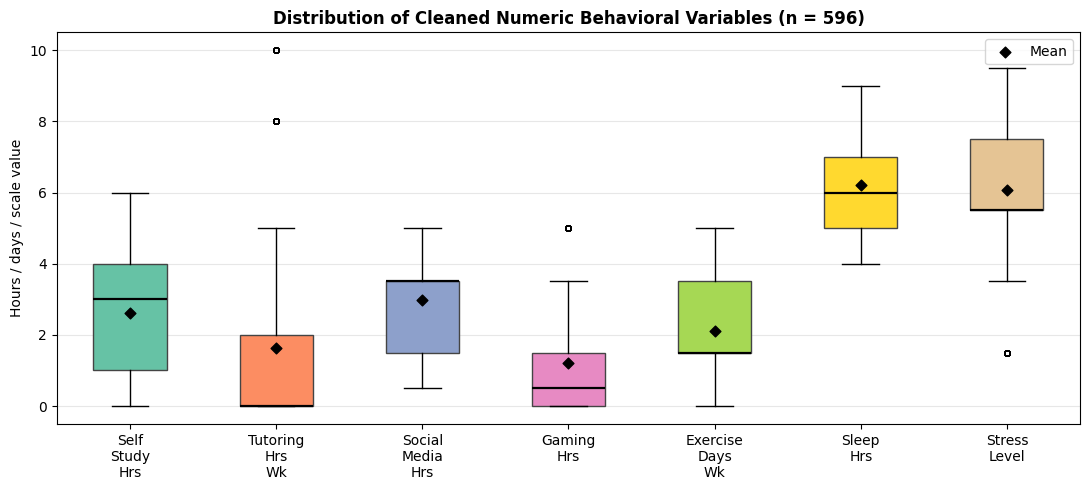

In [3]:
plt.figure(figsize=(10, 6))
behavior_cols = [
    "Self_Study_Hrs", "Tutoring_Hrs_Wk", "Social_Media_Hrs",
    "Gaming_Hrs", "Exercise_Days_Wk", "Sleep_Hrs", "Stress_Level",
]
behavior_cols = [c for c in behavior_cols if c in df.columns]  # keep only existing

fig, ax = plt.subplots(figsize=(11, 5))
palette = sns.color_palette("Set2", len(behavior_cols))

bp = ax.boxplot(
    [df[c].dropna() for c in behavior_cols],
    labels=[c.replace("_", "\n") for c in behavior_cols],
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1.6),
    flierprops=dict(marker="o", markersize=4, alpha=0.4),
)
for patch, color in zip(bp["boxes"], palette):
    patch.set_facecolor(color)
    patch.set_edgecolor("#444444")

# overlay the mean of each variable as a black diamond
means = [df[c].dropna().mean() for c in behavior_cols]
ax.scatter(range(1, len(behavior_cols) + 1), means,
           color="black", marker="D", s=30, zorder=5, label="Mean")

ax.set_ylabel("Hours / days / scale value")
ax.set_title("Distribution of Cleaned Numeric Behavioral Variables (n = {})".format(len(df)),
             fontsize=12, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

Univeristy Distribution

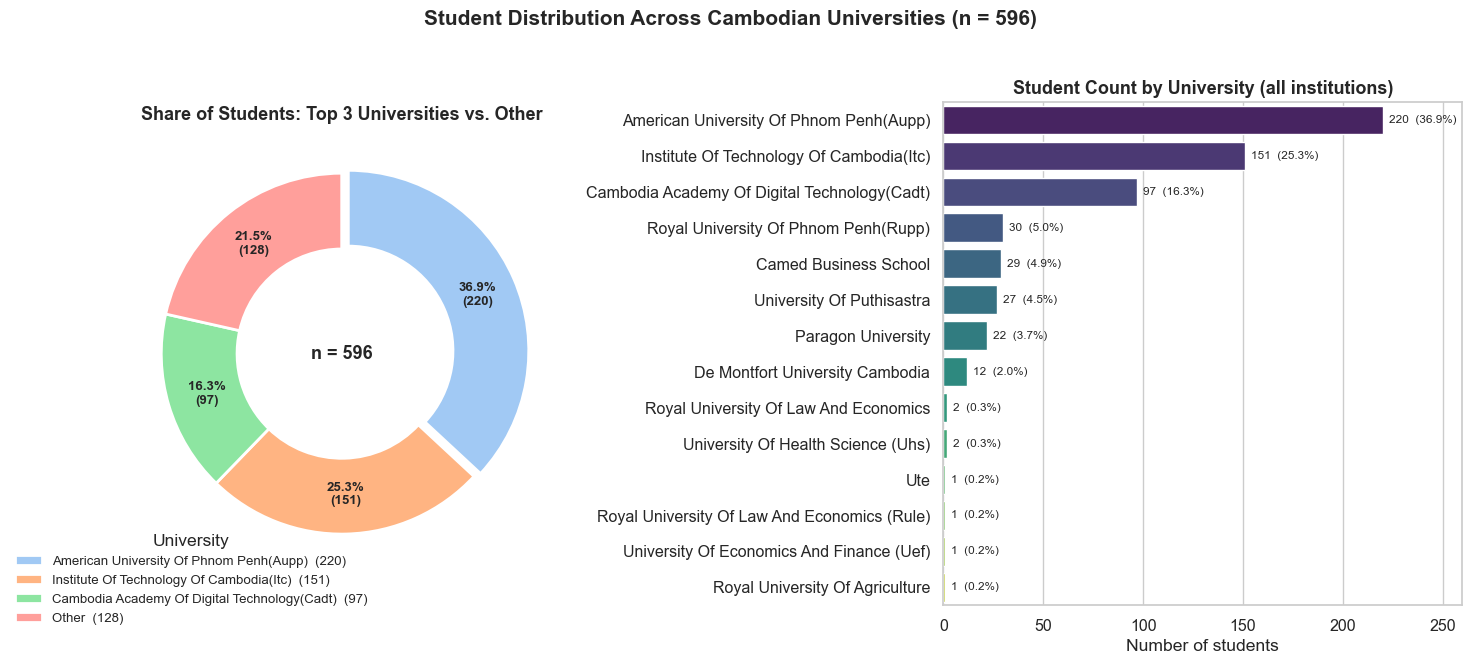

In [11]:
# ── EDA: University distribution (top-3 + Other) ─────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)

uni_counts = df["University"].value_counts()
total = uni_counts.sum()

# Keep the top 3 universities; collapse the rest into "Other"
top3 = uni_counts.head(3)
other = uni_counts.iloc[3:].sum()
pie_data = top3.copy()
if other > 0:
    pie_data["Other"] = other

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5),
                               gridspec_kw={"width_ratios": [1, 1.15]})

# ── Left: 4-slice donut (top 3 + Other) ──
pie_colors = sns.color_palette("pastel", len(pie_data))
explode = [0.04, 0, 0, 0][:len(pie_data)]  # nudge the largest slice out slightly

wedges, _, autotexts = ax1.pie(
    pie_data.values,
    labels=None,
    autopct=lambda p: f"{p:.1f}%\n({int(round(p/100*pie_data.sum()))})",
    startangle=90,
    counterclock=False,
    colors=pie_colors,
    explode=explode,
    pctdistance=0.78,
    wedgeprops=dict(edgecolor="white", linewidth=2, width=0.42),  # donut
)
for at in autotexts:
    at.set_fontsize(9.5); at.set_fontweight("bold")
ax1.legend(wedges, [f"{u}  ({c})" for u, c in pie_data.items()],
           title="University", loc="center left",
           bbox_to_anchor=(-0.25, 0.0), fontsize=9.5, frameon=False)
ax1.set_title("Share of Students: Top 3 Universities vs. Other",
              fontsize=13, fontweight="bold")
ax1.text(0, 0, f"n = {total}", ha="center", va="center",
         fontsize=13, fontweight="bold")

# ── Right: full ranked bar chart (all institutions, for detail) ──
sns.barplot(x=uni_counts.values, y=uni_counts.index,
            hue=uni_counts.index, palette="viridis",
            legend=False, ax=ax2)
for i, v in enumerate(uni_counts.values):
    ax2.text(v + total * 0.005, i, f"{v}  ({v/total*100:.1f}%)",
             va="center", fontsize=8.5)
ax2.set_xlabel("Number of students")
ax2.set_ylabel("")
ax2.set_xlim(0, uni_counts.max() * 1.18)
ax2.set_title("Student Count by University (all institutions)",
              fontsize=13, fontweight="bold")

fig.suptitle(f"Student Distribution Across Cambodian Universities (n = {total})",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

Corelation_Heatmap


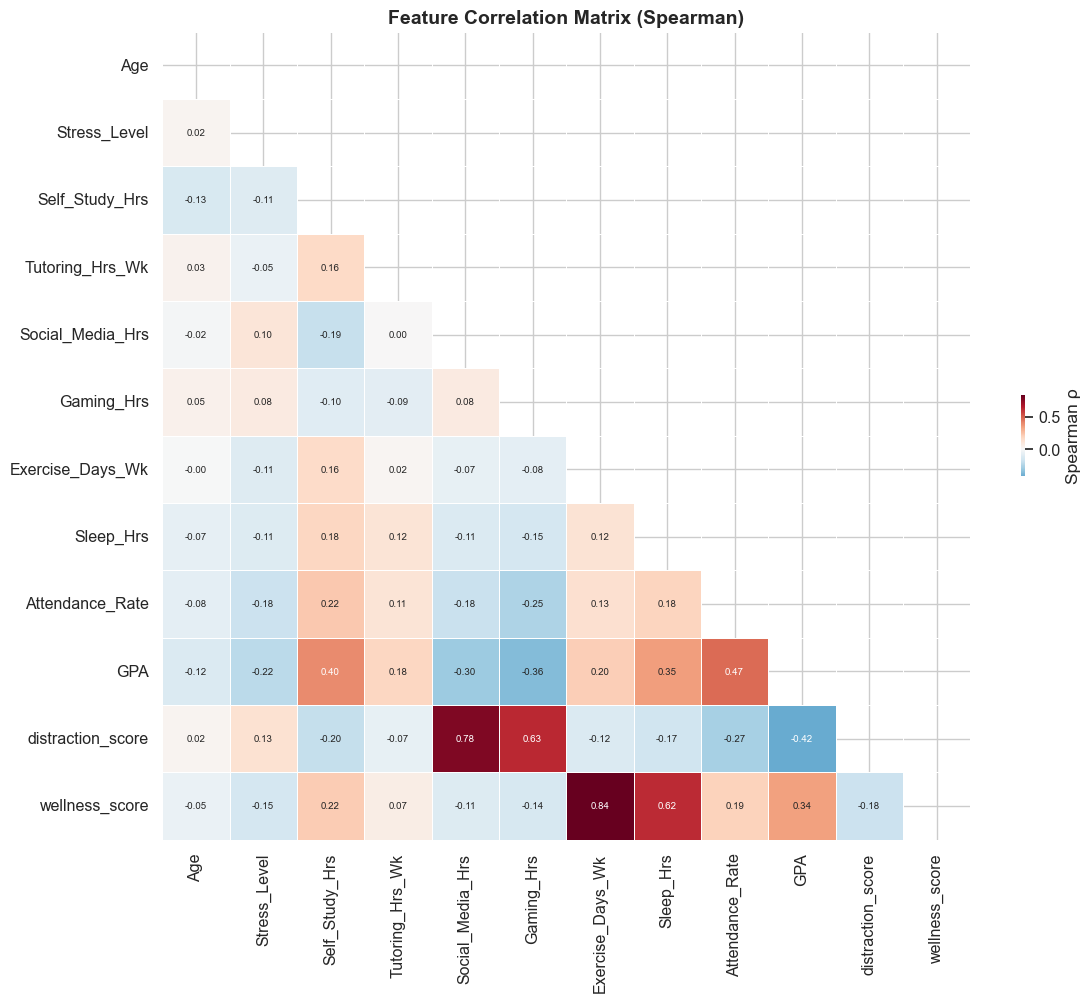

In [13]:
num = df.select_dtypes(include=np.number)
corr = num.corr(method="spearman")
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 7}, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.1, "label": "Spearman ρ"}, ax=ax)
ax.set_title("Feature Correlation Matrix (Spearman)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

 GPA vs. feature with LOWESS trend 

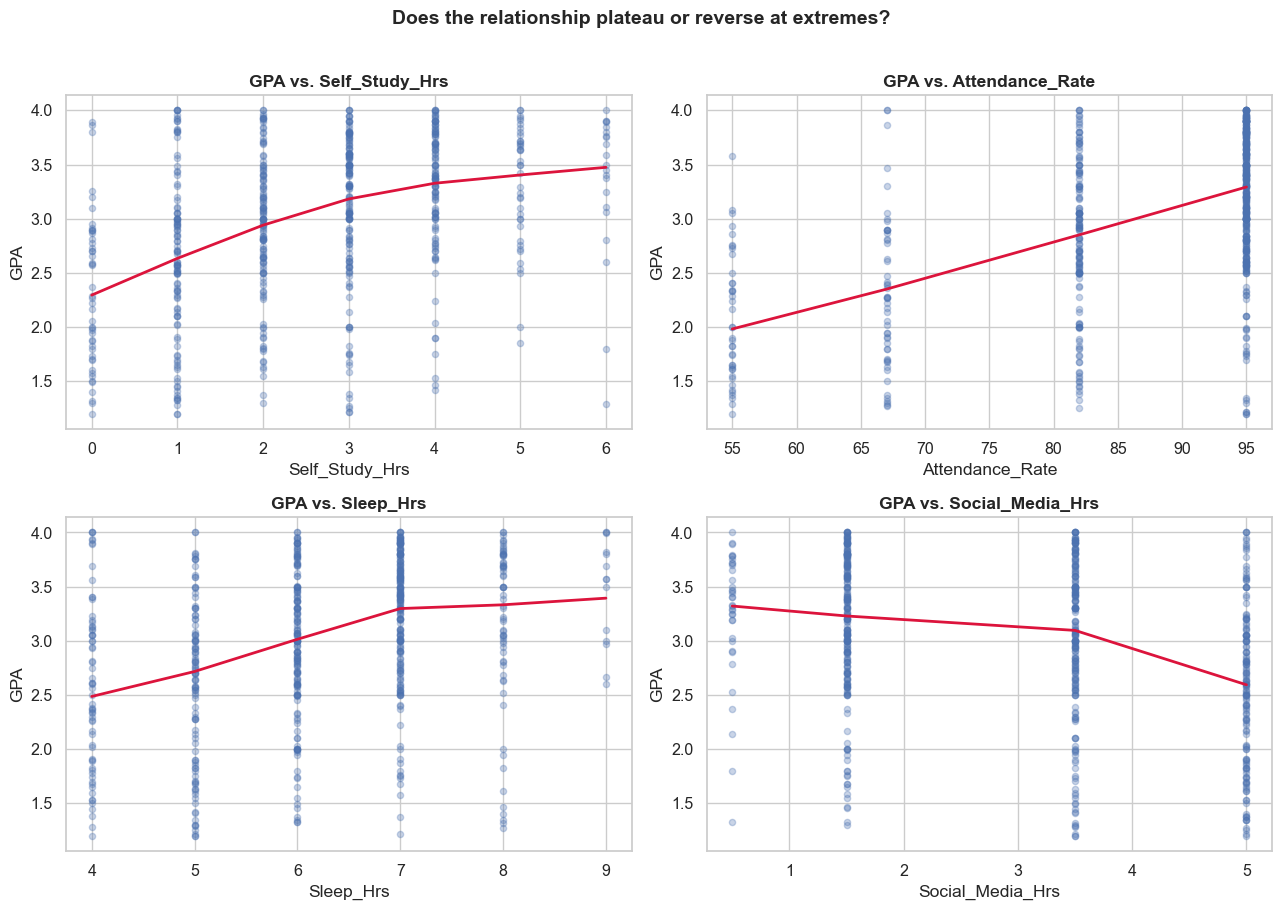

In [14]:
features = [c for c in ["Self_Study_Hrs", "Attendance_Rate", "Sleep_Hrs", "Social_Media_Hrs"] if c in df.columns]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, feat in zip(axes.flat, features):
    sns.regplot(data=df, x=feat, y="GPA", scatter_kws={"alpha": 0.3, "s": 20},
                lowess=True, line_kws={"color": "crimson", "lw": 2}, ax=ax)
    ax.set_title(f"GPA vs. {feat}", fontweight="bold")
fig.suptitle("Does the relationship plateau or reverse at extremes?", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

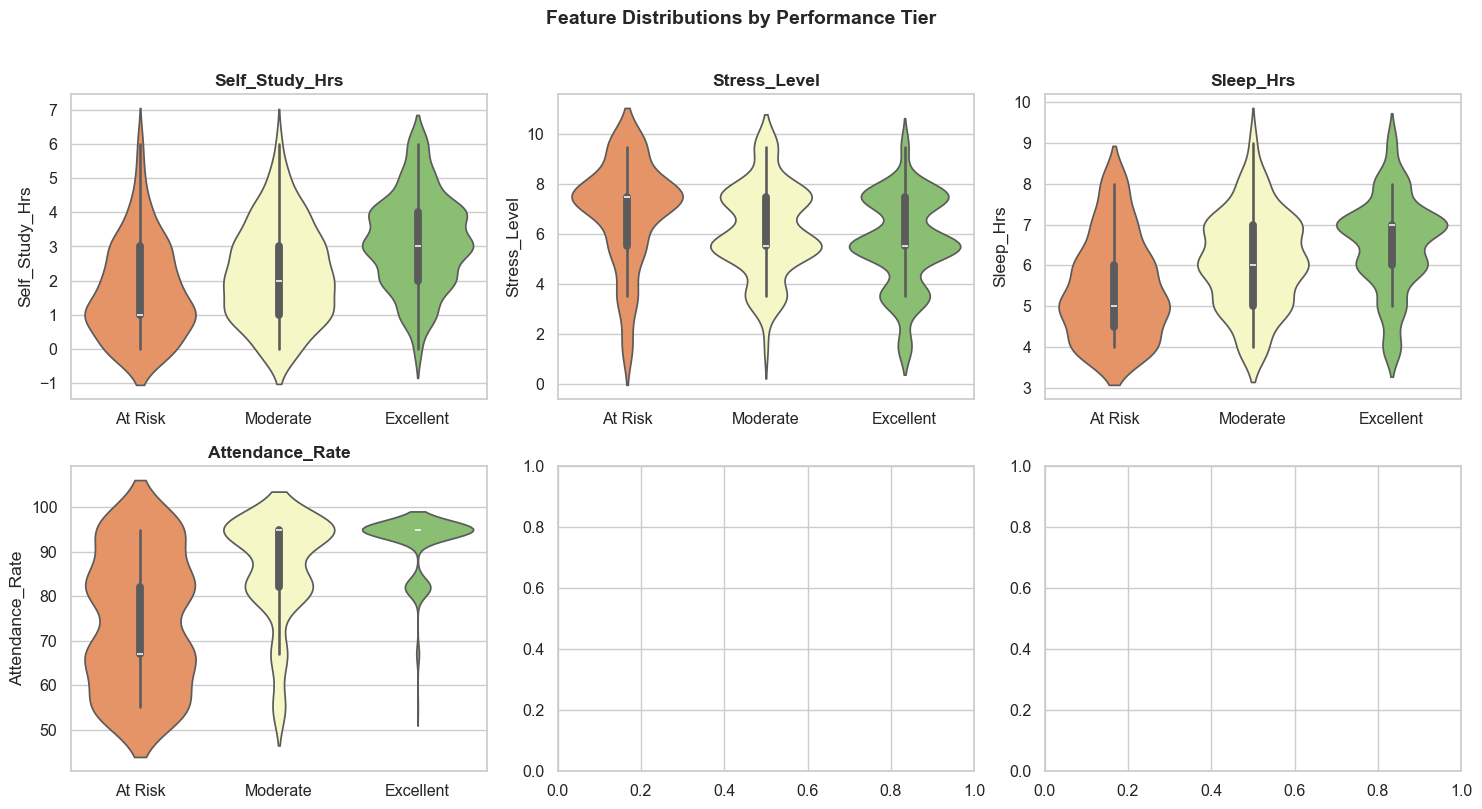

In [19]:
tier_map = {
    "At-Risk":                 "At Risk",
    "Fair / Average":          "Moderate",
    "Very Good / Good":        "Excellent",
    "Outstanding / Excellent": "Excellent",
}
tier_order = ["At Risk", "Moderate", "Excellent"]

df["Tier_Label"] = df["Performance_Tier"].map(tier_map)
tier_feats = [c for c in ["Self_Study_Hrs", "Distraction_Hrs", "Stress_Level",
                          "Sleep_Hrs", "Attendance_Rate", "Study_Distraction_Ratio"] if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, tier_feats):
    sns.violinplot(data=df, x="Tier_Label", y=feat, hue="Tier_Label",
                   order=tier_order, hue_order=tier_order,
                   palette="RdYlGn", legend=False, ax=ax)
    ax.set_title(feat, fontweight="bold")
    ax.set_xlabel("")
fig.suptitle("Feature Distributions by Performance Tier", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

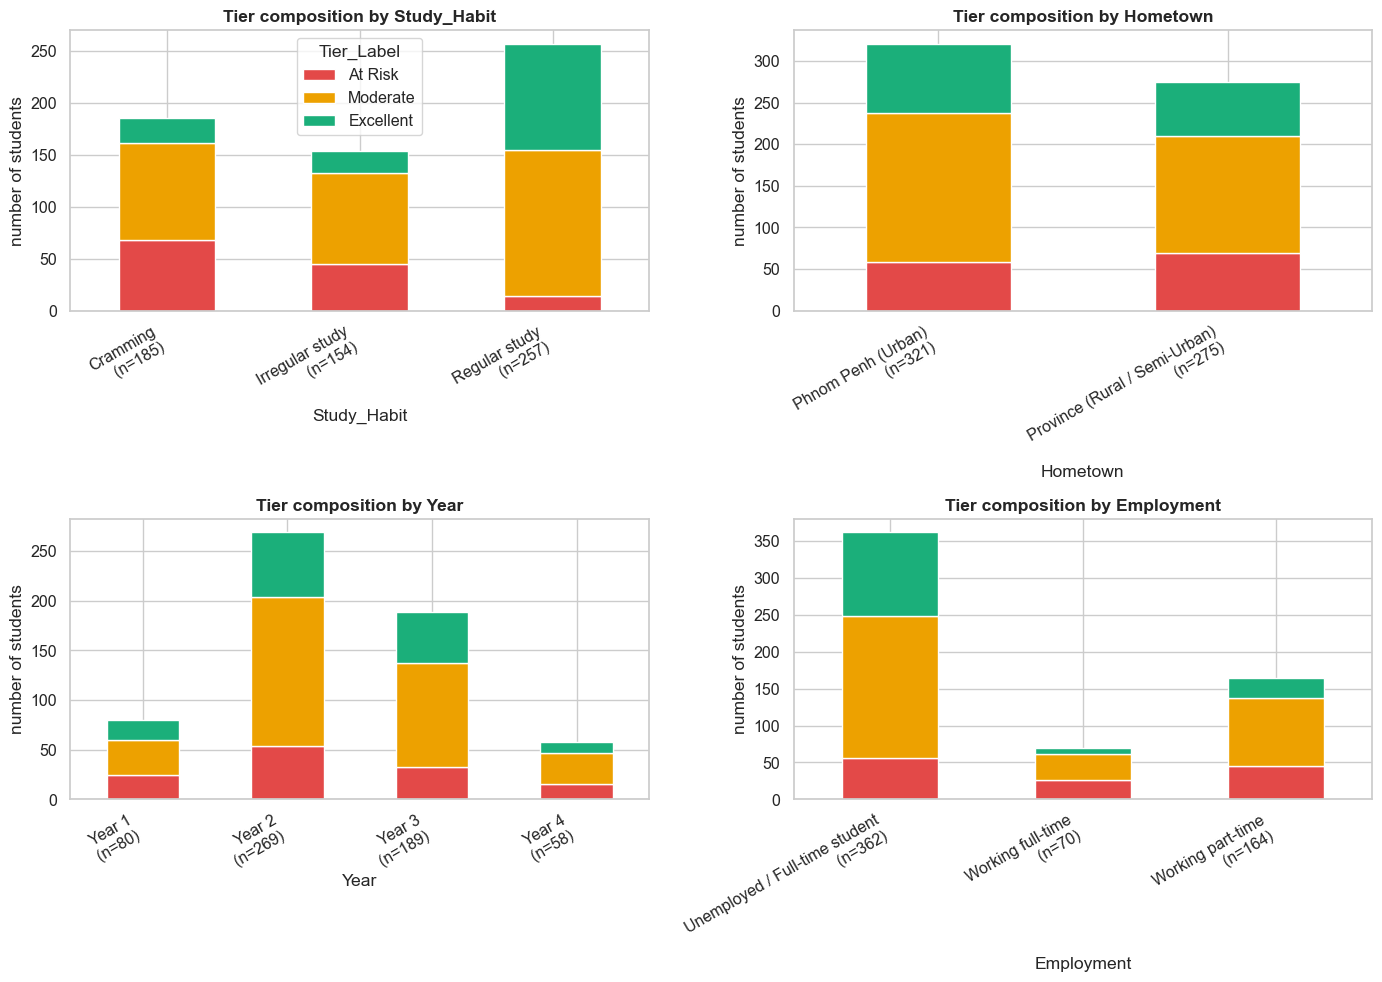

In [42]:
tier_map = {
    "At-Risk":                 "At Risk",
    "Fair / Average":          "Moderate",
    "Very Good / Good":        "Moderate",
    "Outstanding / Excellent": "Excellent",
}
tier_order = ["At Risk", "Moderate", "Excellent"]

TIER_COLORS = ['#2a78d6', '#1baf7a', '#eda100', '#e34948']
# pick colors per tier: At Risk=red, Moderate=amber, Excellent=green
color_map = {"At Risk": '#e34948', "Moderate": '#eda100', "Excellent": '#1baf7a'}

df["Tier_Label"] = df["Performance_Tier"].map(tier_map)
cats = [c for c in ["Study_Habit", "Hometown", "Year", "Employment"] if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, cat in zip(axes.flat, cats):
    ct = (pd.crosstab(df[cat], df["Tier_Label"])[tier_order])[tier_order]
    n = df[cat].value_counts()
    ct.plot(kind="bar", stacked=True,
            color=[color_map[t] for t in tier_order],   # ← fixed
            ax=ax, edgecolor="white", legend=(ax is axes.flat[0]))
    ax.set_title(f"Tier composition by {cat}", fontweight="bold")
    ax.set_ylabel("number of students")
    ax.set_xticklabels([f"{lbl.get_text()}\n(n={n[lbl.get_text()]})"
                        for lbl in ax.get_xticklabels()], rotation=30, ha="right")

plt.tight_layout()
plt.show()

---
## Q1 — Do composite scores predict GPA better than raw columns?
> We add `Social_Media_Hrs + Gaming_Hrs` into one `distraction_score`, and `Sleep_Hrs + Exercise_Days_Wk` into one `wellness_score`. Then we check if the combined score has a stronger correlation with GPA than each column alone. **If the composite number is further from 0, it is a better predictor.**

In [14]:
cols = ['Social_Media_Hrs', 'Gaming_Hrs', 'distraction_score',
        'Sleep_Hrs', 'Exercise_Days_Wk', 'wellness_score']

print(df[cols + ['GPA']].corr()['GPA'].drop('GPA').sort_values().round(3))
# distraction_score should be more negative than both raw columns → composite wins

distraction_score   -0.448
Gaming_Hrs          -0.362
Social_Media_Hrs    -0.298
Exercise_Days_Wk     0.192
wellness_score       0.336
Sleep_Hrs            0.339
Name: GPA, dtype: float64


---
## Q2 — How is GPA distributed across tiers? Any outliers?
> We check if the tier labels (Outstanding, Very Good, Fair, At-Risk) actually match GPA values. We also look for unusual cases — like an At-Risk student who somehow has a high GPA. **If tiers and GPA match cleanly, the labels are trustworthy.**

                         count  mean   std  min   25%   50%   75%   max
Performance_Tier                                                       
At-Risk                  127.0  1.86  0.40  1.2  1.55  1.83  2.17  3.56
Fair / Average           151.0  2.77  0.24  2.0  2.60  2.75  2.90  3.75
Outstanding / Excellent  148.0  3.78  0.15  3.5  3.65  3.80  3.90  4.00
Very Good / Good         170.0  3.29  0.23  3.0  3.10  3.28  3.42  4.00


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5268\4188631280.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Performance_Tier', y='GPA',


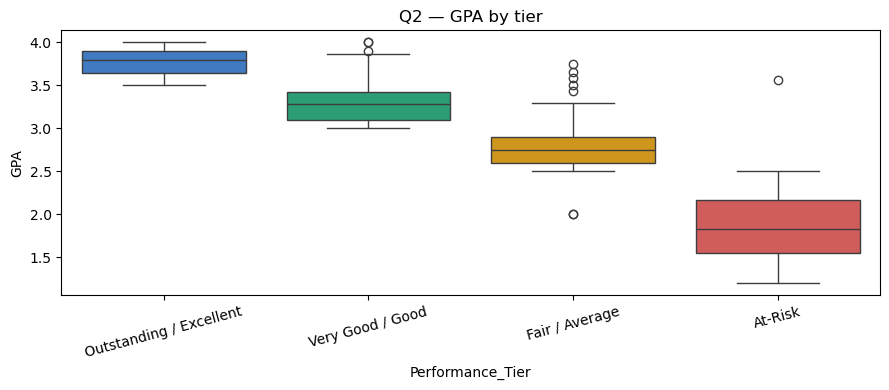

At-Risk outliers (GPA > 3.0): 1
     GPA  Attendance_Rate    Study_Habit
70  3.56             95.0  Regular study


In [15]:
print(df.groupby('Performance_Tier')['GPA'].describe().round(2))

plt.figure(figsize=(9, 4))
sns.boxplot(data=df, x='Performance_Tier', y='GPA',
            order=TIER_ORDER, palette=TIER_COLORS)
plt.title('Q2 — GPA by tier')
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

out = df[(df['Performance_Tier'] == 'At-Risk') & (df['GPA'] > 3.0)]
print(f'At-Risk outliers (GPA > 3.0): {len(out)}')
print(out[['GPA', 'Attendance_Rate', 'Study_Habit']])

---
## Q3 — Does more self-study predict higher GPA, or does it plateau?
> We plot self-study hours against GPA to see if the relationship keeps going up, or flattens at some point. The scatter shows individual students; the bar chart shows average GPA per study-hour range. **If bars keep rising, more study always helps. If they flatten, there is a limit.**

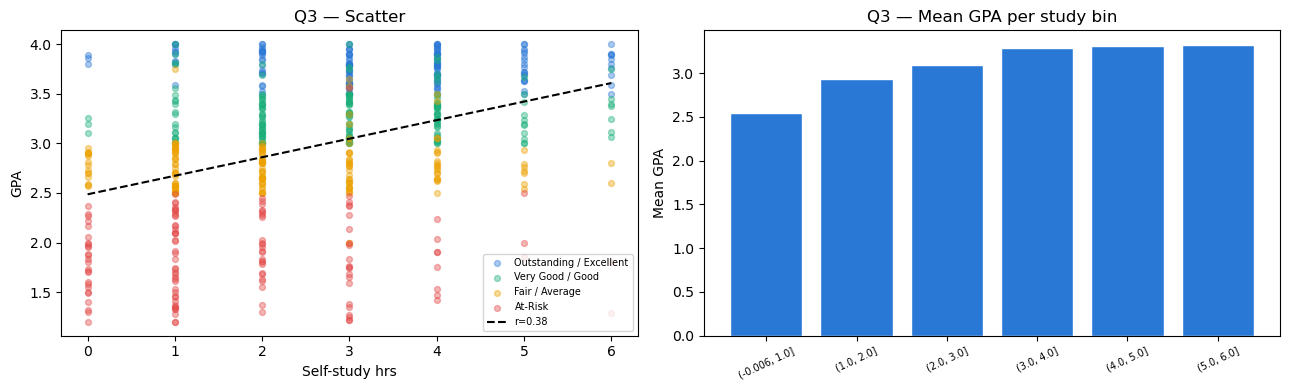

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for tier, color in zip(TIER_ORDER, TIER_COLORS):
    sub = df[df['Performance_Tier'] == tier]
    axes[0].scatter(sub['Self_Study_Hrs'], sub['GPA'], alpha=0.4, s=18, color=color, label=tier)
m, b, r, *_ = stats.linregress(df['Self_Study_Hrs'], df['GPA'])
x = np.linspace(df['Self_Study_Hrs'].min(), df['Self_Study_Hrs'].max(), 100)
axes[0].plot(x, m*x+b, 'k--', label=f'r={r:.2f}')
axes[0].set(xlabel='Self-study hrs', ylabel='GPA', title='Q3 — Scatter')
axes[0].legend(fontsize=7)

df['study_bin'] = pd.cut(df['Self_Study_Hrs'], bins=6)
means = df.groupby('study_bin', observed=True)['GPA'].mean()
axes[1].bar(range(len(means)), means.values, color='#2a78d6', edgecolor='white')
axes[1].set_xticks(range(len(means)))
axes[1].set_xticklabels([str(b) for b in means.index], rotation=25, fontsize=7)
axes[1].set(ylabel='Mean GPA', title='Q3 — Mean GPA per study bin')
df.drop(columns='study_bin', inplace=True)

plt.tight_layout(); plt.show()

---
## Q4 — Do regular studiers outperform crammers across all tiers?
> We compare GPA across three study habits: regular study, cramming, and irregular study. The boxplot shows GPA spread; the bar chart shows how each tier is made up of different study habits. **If regular study dominates the top tiers, it is a strong actionable finding.**

                 mean   std  count
Study_Habit                       
Cramming         2.65  0.74    185
Irregular study  2.76  0.72    154
Regular study    3.34  0.55    257


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5268\3769139301.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Study_Habit', y='GPA', order=habit_order, palette='Set2', ax=axes[0])


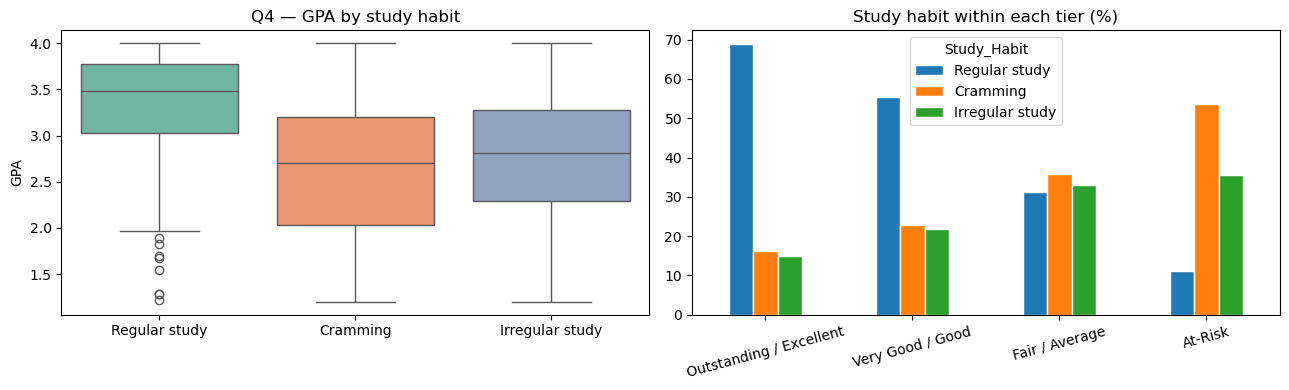

In [17]:
habit_order = ['Regular study', 'Cramming', 'Irregular study']
print(df.groupby('Study_Habit')['GPA'].agg(['mean','std','count']).round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=df, x='Study_Habit', y='GPA', order=habit_order, palette='Set2', ax=axes[0])
axes[0].set(title='Q4 — GPA by study habit', xlabel='')

ct = pd.crosstab(df['Performance_Tier'], df['Study_Habit'], normalize='index') * 100
ct[habit_order].reindex(TIER_ORDER).plot(kind='bar', ax=axes[1], edgecolor='white')
axes[1].set(title='Study habit within each tier (%)', xlabel='')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout(); plt.show()

---
## Q5 — Is there an attendance threshold where students drop to At-Risk?
> We plot attendance rate against GPA and draw a vertical line at 80% to see if most At-Risk students cluster below it. The boxplot shows average attendance per tier. **If At-Risk students mostly fall below 80%, that becomes a useful early warning threshold.**

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5268\342342121.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Performance_Tier', y='Attendance_Rate',


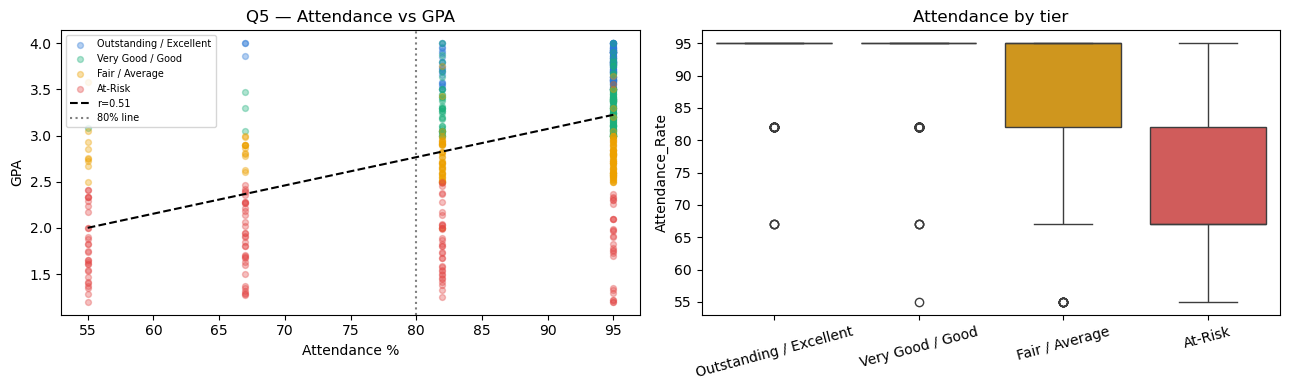

Performance_Tier
Outstanding / Excellent    92.6
Very Good / Good           91.4
Fair / Average             86.2
At-Risk                    74.5
Name: Attendance_Rate, dtype: float64


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for tier, color in zip(TIER_ORDER, TIER_COLORS):
    sub = df[df['Performance_Tier'] == tier]
    axes[0].scatter(sub['Attendance_Rate'], sub['GPA'], alpha=0.35, s=18, color=color, label=tier)
m, b, r, *_ = stats.linregress(df['Attendance_Rate'], df['GPA'])
x = np.linspace(df['Attendance_Rate'].min(), df['Attendance_Rate'].max(), 100)
axes[0].plot(x, m*x+b, 'k--', label=f'r={r:.2f}')
axes[0].axvline(80, color='gray', linestyle=':', label='80% line')
axes[0].set(xlabel='Attendance %', ylabel='GPA', title='Q5 — Attendance vs GPA')
axes[0].legend(fontsize=7)

sns.boxplot(data=df, x='Performance_Tier', y='Attendance_Rate',
            order=TIER_ORDER, palette=TIER_COLORS, ax=axes[1])
axes[1].set(title='Attendance by tier', xlabel='')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout(); plt.show()
print(df.groupby('Performance_Tier')['Attendance_Rate'].mean().reindex(TIER_ORDER).round(1))

---
## Q6 — Does study group frequency relate to performance tier?
> We check if students who study in groups more often end up in higher tiers. The boxplot shows GPA by group frequency; the bar chart shows how each tier breaks down by group habits. **If 'Never' group study is concentrated in At-Risk, group studying is a helpful behavior to encourage.**

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5268\913965367.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Study_Group_Freq', y='GPA', order=sg_order, palette='Blues', ax=axes[0])


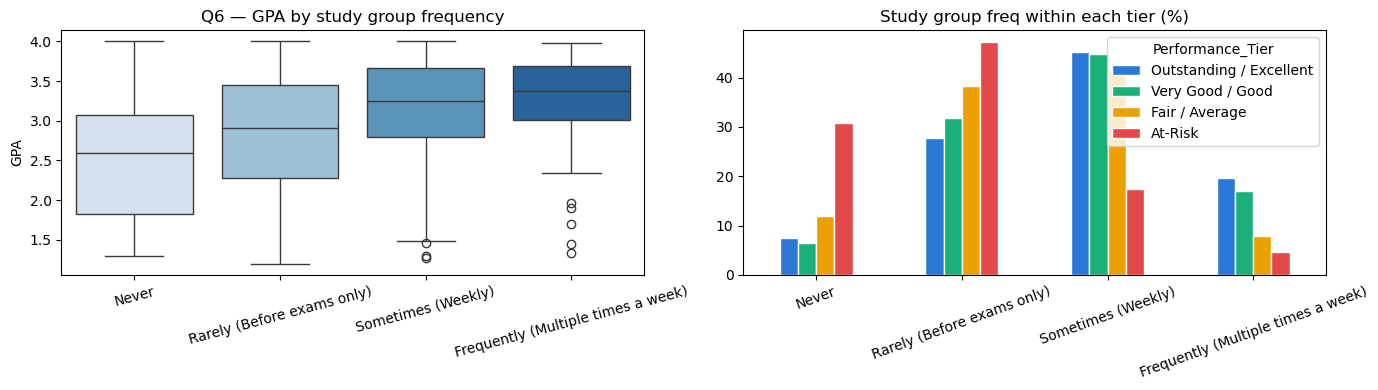

In [19]:
sg_order = ['Never', 'Rarely (Before exams only)',
            'Sometimes (Weekly)', 'Frequently (Multiple times a week)']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=df, x='Study_Group_Freq', y='GPA', order=sg_order, palette='Blues', ax=axes[0])
axes[0].set(title='Q6 — GPA by study group frequency', xlabel='')
axes[0].tick_params(axis='x', rotation=15)

ct = pd.crosstab(df['Study_Group_Freq'], df['Performance_Tier'], normalize='columns') * 100
ct.reindex(sg_order)[TIER_ORDER].plot(kind='bar', ax=axes[1], color=TIER_COLORS, edgecolor='white')
axes[1].set(title='Study group freq within each tier (%)', xlabel='')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout(); plt.show()

---
## Q7 — Does sleep correlate with GPA? Is there a sweet spot?
> We plot sleep hours against GPA to find the optimal sleep range. The scatter shows the trend line; the boxplot compares sleep hours across tiers. **If the line keeps going up with no dip, more sleep always helps. If it curves down at high hours, there is a sweet spot.**

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5268\546017533.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Performance_Tier', y='Sleep_Hrs',


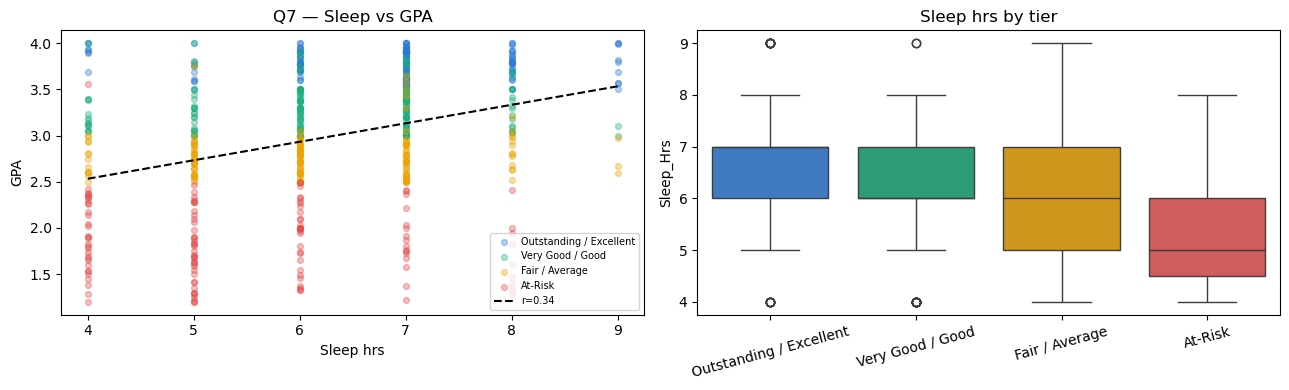

Performance_Tier
Outstanding / Excellent    6.82
Very Good / Good           6.28
Fair / Average             6.12
At-Risk                    5.46
Name: Sleep_Hrs, dtype: float64


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for tier, color in zip(TIER_ORDER, TIER_COLORS):
    sub = df[df['Performance_Tier'] == tier]
    axes[0].scatter(sub['Sleep_Hrs'], sub['GPA'], alpha=0.35, s=18, color=color, label=tier)
m, b, r, *_ = stats.linregress(df['Sleep_Hrs'], df['GPA'])
x = np.linspace(df['Sleep_Hrs'].min(), df['Sleep_Hrs'].max(), 100)
axes[0].plot(x, m*x+b, 'k--', label=f'r={r:.2f}')
axes[0].set(xlabel='Sleep hrs', ylabel='GPA', title='Q7 — Sleep vs GPA')
axes[0].legend(fontsize=7)

sns.boxplot(data=df, x='Performance_Tier', y='Sleep_Hrs',
            order=TIER_ORDER, palette=TIER_COLORS, ax=axes[1])
axes[1].set(title='Sleep hrs by tier', xlabel='')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout(); plt.show()
print(df.groupby('Performance_Tier')['Sleep_Hrs'].mean().reindex(TIER_ORDER).round(2))

---
## Q8 — Do social media and gaming together predict lower GPA, or just one?
> We make three scatter plots side by side — social media alone, gaming alone, and the combined distraction score — and compare the r values. **The one with the most negative r value is the strongest predictor. If the combined score wins, use it in your model instead of the raw columns.**

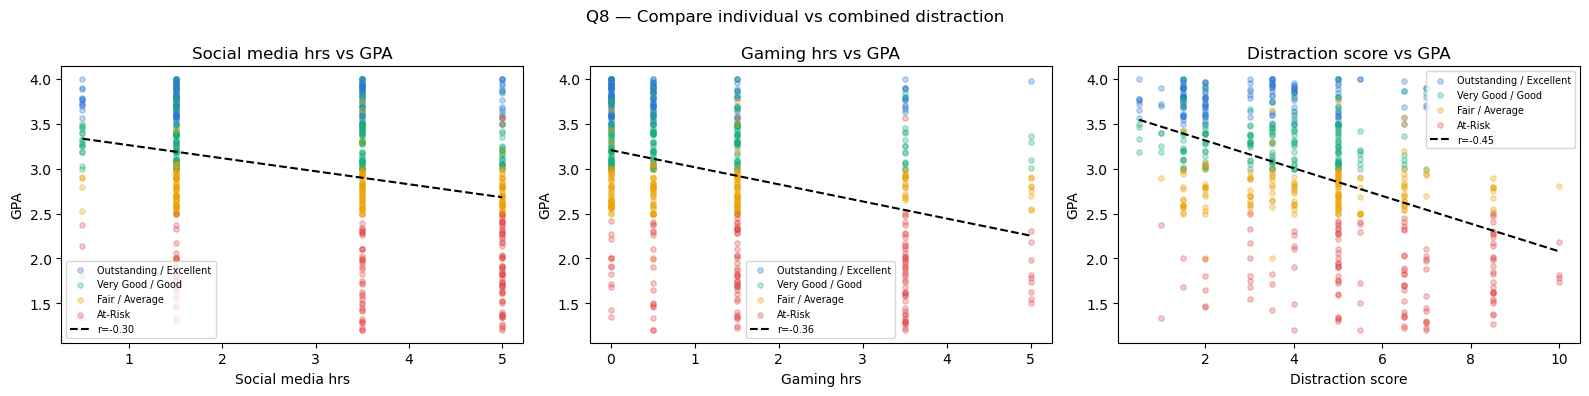

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, label in zip(axes,
        ['Social_Media_Hrs', 'Gaming_Hrs', 'distraction_score'],
        ['Social media hrs', 'Gaming hrs', 'Distraction score']):
    for tier, color in zip(TIER_ORDER, TIER_COLORS):
        sub = df[df['Performance_Tier'] == tier]
        ax.scatter(sub[col], sub['GPA'], alpha=0.3, s=15, color=color, label=tier)
    m, b, r, *_ = stats.linregress(df[col], df['GPA'])
    x = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x, m*x+b, 'k--', label=f'r={r:.2f}')
    ax.set(xlabel=label, ylabel='GPA', title=f'{label} vs GPA')
    ax.legend(fontsize=7)

plt.suptitle('Q8 — Compare individual vs combined distraction')
plt.tight_layout(); plt.show()

---
## Q9 — Does stress level differ significantly by tier?
> We compare stress levels across tiers using a boxplot and a density curve. The density curve shows the full distribution shape — not just the average. **If At-Risk students are clearly more stressed than Outstanding students, stress is a real signal worth including in the model.**

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5268\1478299822.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Performance_Tier', y='Stress_Level',


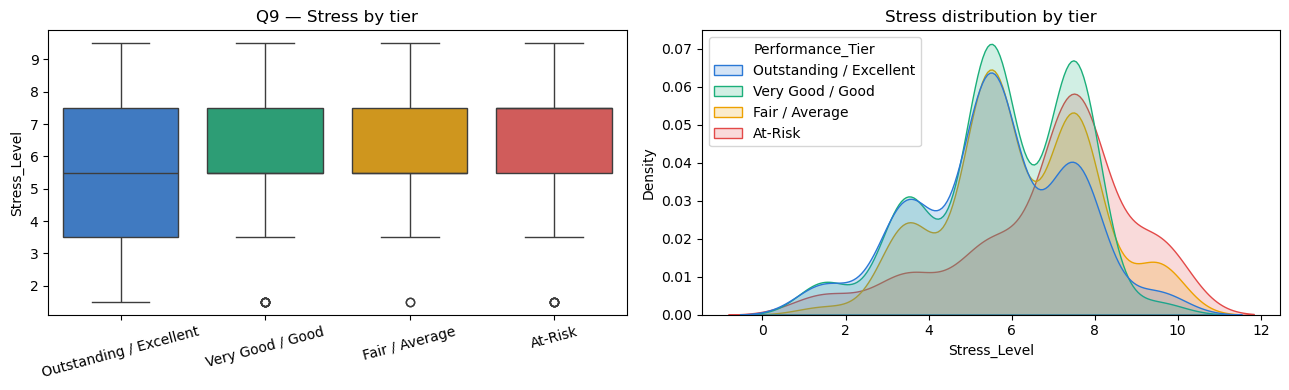

                         mean   std
Performance_Tier                   
Outstanding / Excellent  5.58  1.85
Very Good / Good         5.78  1.77
Fair / Average           6.16  1.77
At-Risk                  6.85  2.05


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(data=df, x='Performance_Tier', y='Stress_Level',
            order=TIER_ORDER, palette=TIER_COLORS, ax=axes[0])
axes[0].set(title='Q9 — Stress by tier', xlabel='')
axes[0].tick_params(axis='x', rotation=15)

sns.kdeplot(data=df, x='Stress_Level', hue='Performance_Tier',
            hue_order=TIER_ORDER, palette=TIER_COLORS, fill=True, alpha=0.2, ax=axes[1])
axes[1].set(title='Stress distribution by tier')

plt.tight_layout(); plt.show()
print(df.groupby('Performance_Tier')['Stress_Level'].agg(['mean','std']).reindex(TIER_ORDER).round(2))

---
## Q10 — Does diet quality correlate with GPA tier?
> We check if students who eat better get higher GPAs, or if diet is just noise. The boxplot shows GPA spread per diet level; the bar chart shows how each tier breaks down by diet. **If Good and Excellent diet show similar GPA, diet adds no extra signal and can be dropped from the model.**

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5268\4097389304.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Diet_Quality', y='GPA', order=diet_order, palette='Greens', ax=axes[0])


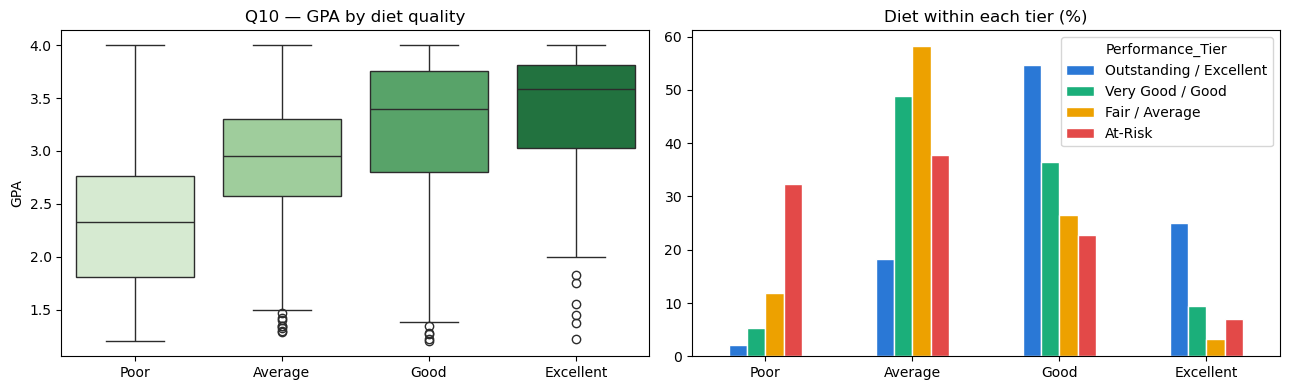

In [24]:
diet_order = ['Poor', 'Average', 'Good', 'Excellent']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=df, x='Diet_Quality', y='GPA', order=diet_order, palette='Greens', ax=axes[0])
axes[0].set(title='Q10 — GPA by diet quality', xlabel='')

ct = pd.crosstab(df['Diet_Quality'], df['Performance_Tier'], normalize='columns') * 100
ct.reindex(diet_order)[TIER_ORDER].plot(kind='bar', ax=axes[1], color=TIER_COLORS, edgecolor='white')
axes[1].set(title='Diet within each tier (%)', xlabel='')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout(); plt.show()

---
## Q11 — Does hometown show a performance gap?
> We compare urban (Phnom Penh) vs province students across tiers, then check if province students have worse internet. **If province students are overrepresented in At-Risk AND have worse internet, it suggests a structural disadvantage — not just study behavior.**

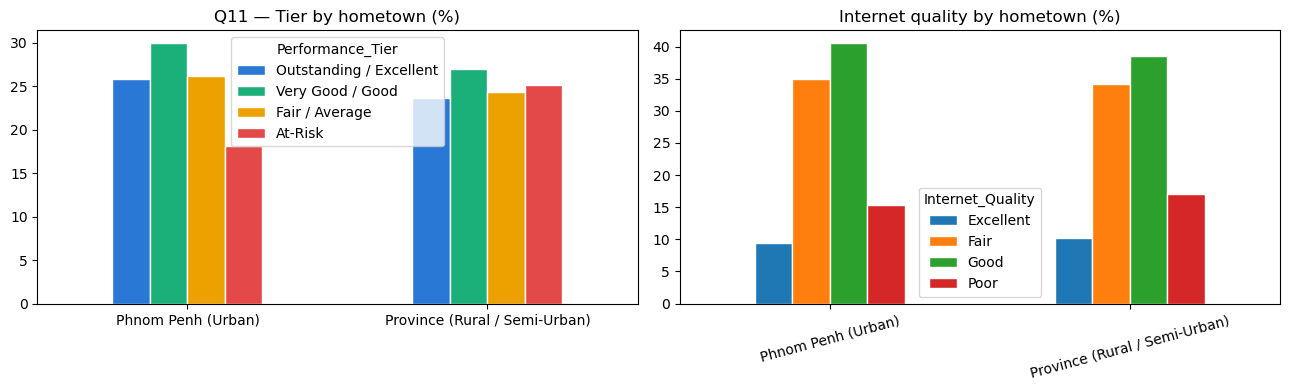

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ct1 = pd.crosstab(df['Hometown'], df['Performance_Tier'], normalize='index') * 100
ct1[TIER_ORDER].plot(kind='bar', ax=axes[0], color=TIER_COLORS, edgecolor='white')
axes[0].set(title='Q11 — Tier by hometown (%)', xlabel='')
axes[0].tick_params(axis='x', rotation=0)

ct2 = pd.crosstab(df['Hometown'], df['Internet_Quality'], normalize='index') * 100
ct2.plot(kind='bar', ax=axes[1], edgecolor='white')
axes[1].set(title='Internet quality by hometown (%)', xlabel='')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout(); plt.show()

---
## Q12 — Does year of study show a GPA progression?
> We check if students improve as they advance through Year 1 to Year 4. The boxplot shows GPA spread per year; the stacked bar shows what % of each year falls in each tier. **If there is no clear upward trend, year of study is a weak feature and not worth including in the model.**

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5268\3370550814.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Year', y='GPA', order=year_order, palette='Purples', ax=axes[0])


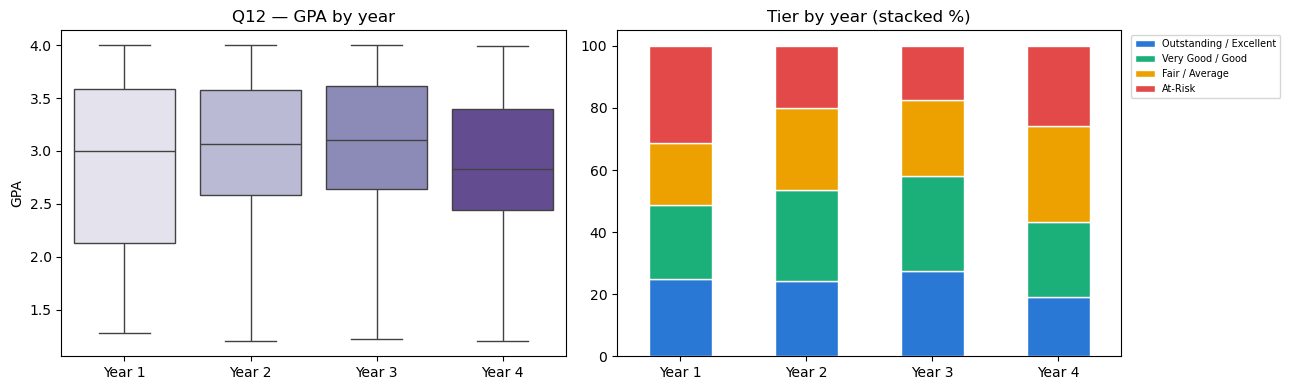

In [27]:
year_order = ['Year 1', 'Year 2', 'Year 3', 'Year 4']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=df, x='Year', y='GPA', order=year_order, palette='Purples', ax=axes[0])
axes[0].set(title='Q12 — GPA by year', xlabel='')

ct = pd.crosstab(df['Year'], df['Performance_Tier'], normalize='index') * 100
ct.reindex(year_order)[TIER_ORDER].plot(kind='bar', stacked=True, ax=axes[1],
                                        color=TIER_COLORS, edgecolor='white')
axes[1].set(title='Tier by year (stacked %)', xlabel='')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(fontsize=7, bbox_to_anchor=(1.01, 1))

plt.tight_layout(); plt.show()

---
## Q13 — Is there a gender gap in GPA or tier?
> We check if male and female students perform differently, and if STEM vs non-STEM major matters. **If the tier split by gender matches the overall 58/42 sample ratio, there is no real gender gap — it is just how the dataset is composed.**

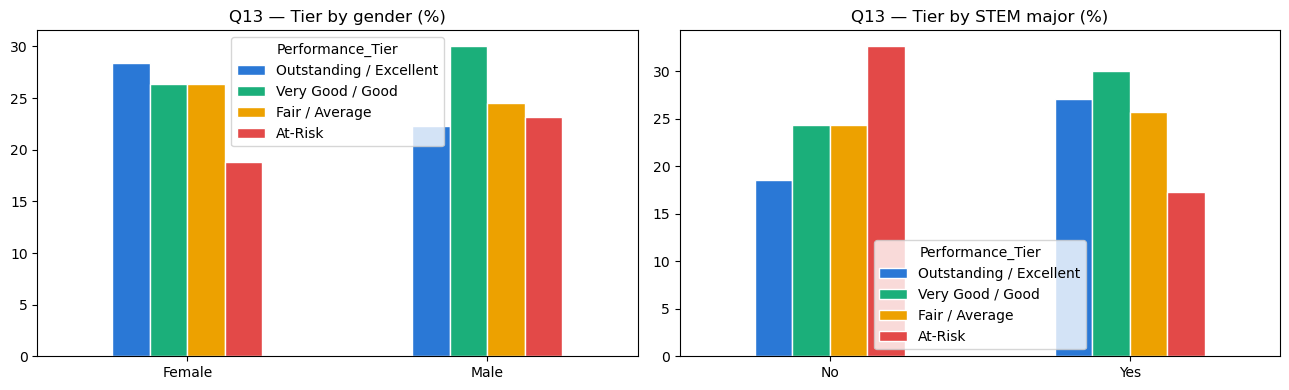

        mean   std
Gender            
Female  3.01  0.72
Male    2.95  0.74


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, title in zip(axes, ['Gender', 'STEM_Major'],
                               ['Tier by gender (%)', 'Tier by STEM major (%)']):
    ct = pd.crosstab(df[col], df['Performance_Tier'], normalize='index') * 100
    ct[TIER_ORDER].plot(kind='bar', ax=ax, color=TIER_COLORS, edgecolor='white')
    ax.set(title=f'Q13 — {title}', xlabel='')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout(); plt.show()
print(df.groupby('Gender')['GPA'].agg(['mean','std']).round(2))

---
## Q14 — Do employed students perform worse?
> We compare GPA across full-time students, part-time workers, and full-time workers. **If the GPA drop is gradual (student → part-time → full-time), employment has a graded cost. If only full-time work hurts, part-time is manageable.**

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5268\4757454.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Employment', y='GPA', order=emp_order,


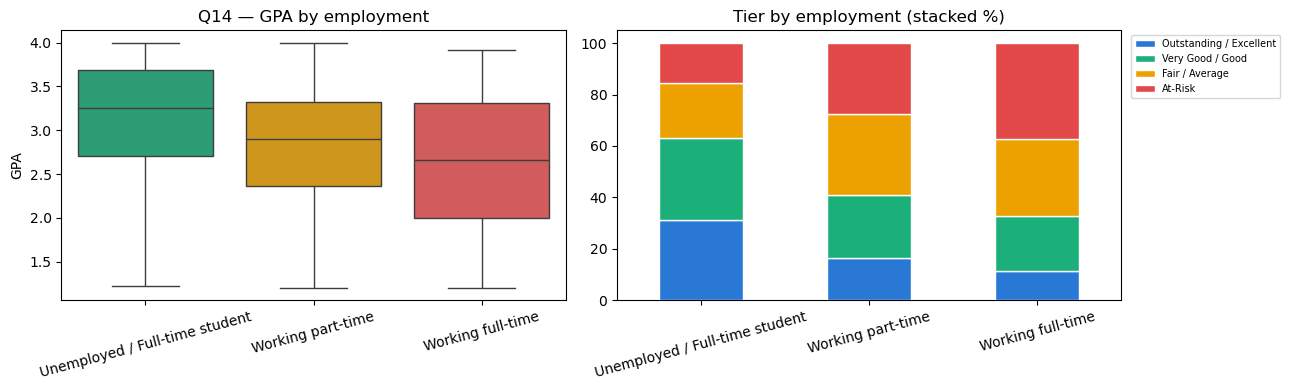

                                mean  count
Employment                                 
Unemployed / Full-time student  3.12    362
Working full-time               2.64     70
Working part-time               2.80    164


In [29]:
emp_order = ['Unemployed / Full-time student', 'Working part-time', 'Working full-time']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=df, x='Employment', y='GPA', order=emp_order,
            palette=['#1baf7a','#eda100','#e34948'], ax=axes[0])
axes[0].set(title='Q14 — GPA by employment', xlabel='')
axes[0].tick_params(axis='x', rotation=15)

ct = pd.crosstab(df['Employment'], df['Performance_Tier'], normalize='index') * 100
ct.reindex(emp_order)[TIER_ORDER].plot(kind='bar', stacked=True, ax=axes[1],
                                       color=TIER_COLORS, edgecolor='white')
axes[1].set(title='Tier by employment (stacked %)', xlabel='')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(fontsize=7, bbox_to_anchor=(1.01, 1))

plt.tight_layout(); plt.show()
print(df.groupby('Employment')['GPA'].agg(['mean','count']).round(2))

---
## Q15 — Does AI tool usage correlate with higher GPA?
> We check if students who use AI tools more often (Never → Always) get better grades. **If the trend is smooth and consistent, AI tools may genuinely help. If it is uneven, frequent AI users might just be more engaged students overall — not because of the AI itself.**

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5268\4160428941.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='AI_Tool_Usage', y='GPA', order=ai_order, palette='Blues', ax=axes[0])


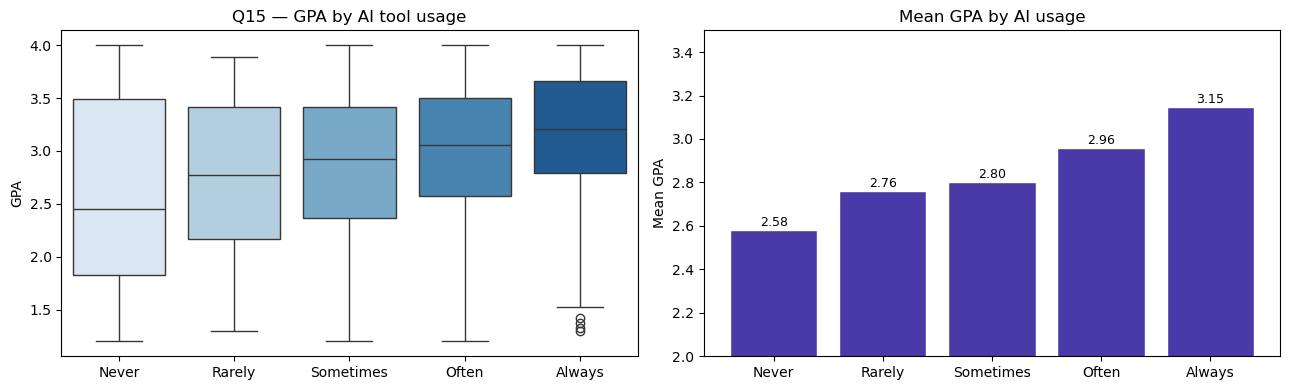

In [30]:
ai_order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Always']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=df, x='AI_Tool_Usage', y='GPA', order=ai_order, palette='Blues', ax=axes[0])
axes[0].set(title='Q15 — GPA by AI tool usage', xlabel='')

means = df.groupby('AI_Tool_Usage')['GPA'].mean().reindex(ai_order)
axes[1].bar(ai_order, means.values, color='#4a3aa7', edgecolor='white')
for i, v in enumerate(means.values):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)
axes[1].set(title='Mean GPA by AI usage', ylabel='Mean GPA', ylim=(2, 3.5))

plt.tight_layout(); plt.show()

---
## Q16 — Does internet quality affect performance?
> We check if students with poor internet are disproportionately At-Risk, and then cross it with hometown to see if province students have worse internet. **If poor internet is heavily concentrated in At-Risk AND province students have worse internet, the two disadvantages compound each other.**

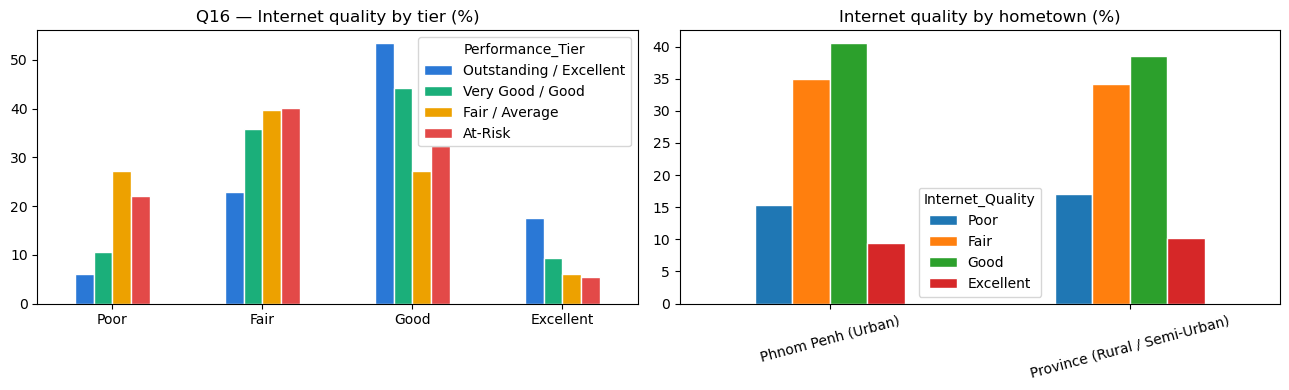

In [31]:
inet_order = ['Poor', 'Fair', 'Good', 'Excellent']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ct1 = pd.crosstab(df['Internet_Quality'], df['Performance_Tier'], normalize='columns') * 100
ct1.reindex(inet_order)[TIER_ORDER].plot(kind='bar', ax=axes[0], color=TIER_COLORS, edgecolor='white')
axes[0].set(title='Q16 — Internet quality by tier (%)', xlabel='')
axes[0].tick_params(axis='x', rotation=0)

ct2 = pd.crosstab(df['Hometown'], df['Internet_Quality'], normalize='index') * 100
ct2[inet_order].plot(kind='bar', ax=axes[1], edgecolor='white')
axes[1].set(title='Internet quality by hometown (%)', xlabel='')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout(); plt.show()

---
## Q17 — Which numeric features correlate most with GPA?
> We run a full correlation matrix on all numeric columns and rank them by strength. The heatmap shows every relationship at once; the ranked list focuses on GPA. **Features close to 0 are weak. Features strongly correlated with each other are redundant — don't use both in a model.**

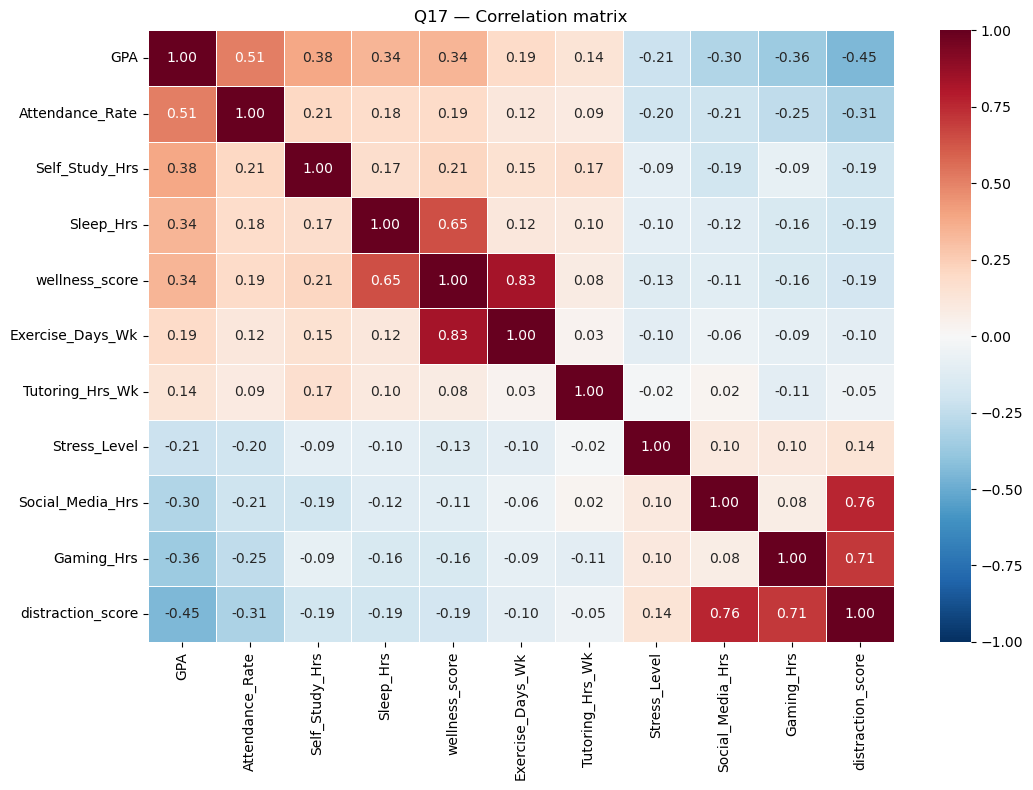

Correlation with GPA (ranked):
Attendance_Rate      0.510
Self_Study_Hrs       0.385
Sleep_Hrs            0.339
wellness_score       0.336
Exercise_Days_Wk     0.192
Tutoring_Hrs_Wk      0.137
Stress_Level        -0.213
Social_Media_Hrs    -0.298
Gaming_Hrs          -0.362
distraction_score   -0.448
Name: GPA, dtype: float64


In [32]:
num_cols = ['GPA', 'Attendance_Rate', 'Self_Study_Hrs', 'Sleep_Hrs', 'wellness_score',
            'Exercise_Days_Wk', 'Tutoring_Hrs_Wk', 'Stress_Level',
            'Social_Media_Hrs', 'Gaming_Hrs', 'distraction_score']

corr = df[num_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.4)
plt.title('Q17 — Correlation matrix'); plt.tight_layout(); plt.show()

print('Correlation with GPA (ranked):')
print(corr['GPA'].drop('GPA').sort_values(ascending=False).round(3))

---
## Q18 — Are there missing values or suspicious columns?
> Before building any model, we check if the data is clean. Missing values break models. Columns where everyone has the same value add zero information. **If all missing value counts are 0 and all columns have variation, the dataset is ready for modeling with no extra cleaning needed.**

In [33]:
print('Missing values:')
print(df.isnull().sum())

print('\nUnique values per column:')
print(df.nunique().sort_values())

print('\nStd deviation (numeric columns):')
print(df.select_dtypes(include='number').std().sort_values().round(3))

Missing values:
Gender               0
Age                  0
Hometown             0
University           0
Year                 0
STEM_Major           0
Diet_Quality         0
Internet_Quality     0
Employment           0
Study_Habit          0
Stress_Level         0
Self_Study_Hrs       0
Tutoring_Hrs_Wk      0
AI_Tool_Usage        0
Social_Media_Hrs     0
Gaming_Hrs           0
Exercise_Days_Wk     0
Sleep_Hrs            0
Attendance_Rate      0
Commute_Time         0
Study_Group_Freq     0
Extracurricular      0
GPA                  0
Performance_Tier     0
distraction_score    0
wellness_score       0
dtype: int64

Unique values per column:
Gender                 2
Hometown               2
STEM_Major             2
Extracurricular        2
Study_Habit            3
Employment             3
Diet_Quality           4
Internet_Quality       4
Social_Media_Hrs       4
Commute_Time           4
Study_Group_Freq       4
Performance_Tier       4
Attendance_Rate        4
Year                 

---
## Q19 — Composite scores vs raw columns — visual confirmation
> This is the same idea as Q1 but confirmed visually with 4 charts. Boxplots show how clearly each score separates the tiers; scatter plots show the trend with GPA. **If the distraction score boxes barely overlap between Outstanding and At-Risk, the composite is working well as a feature.**

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5268\1305939450.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Performance_Tier', y=col,
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5268\1305939450.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Performance_Tier', y=col,


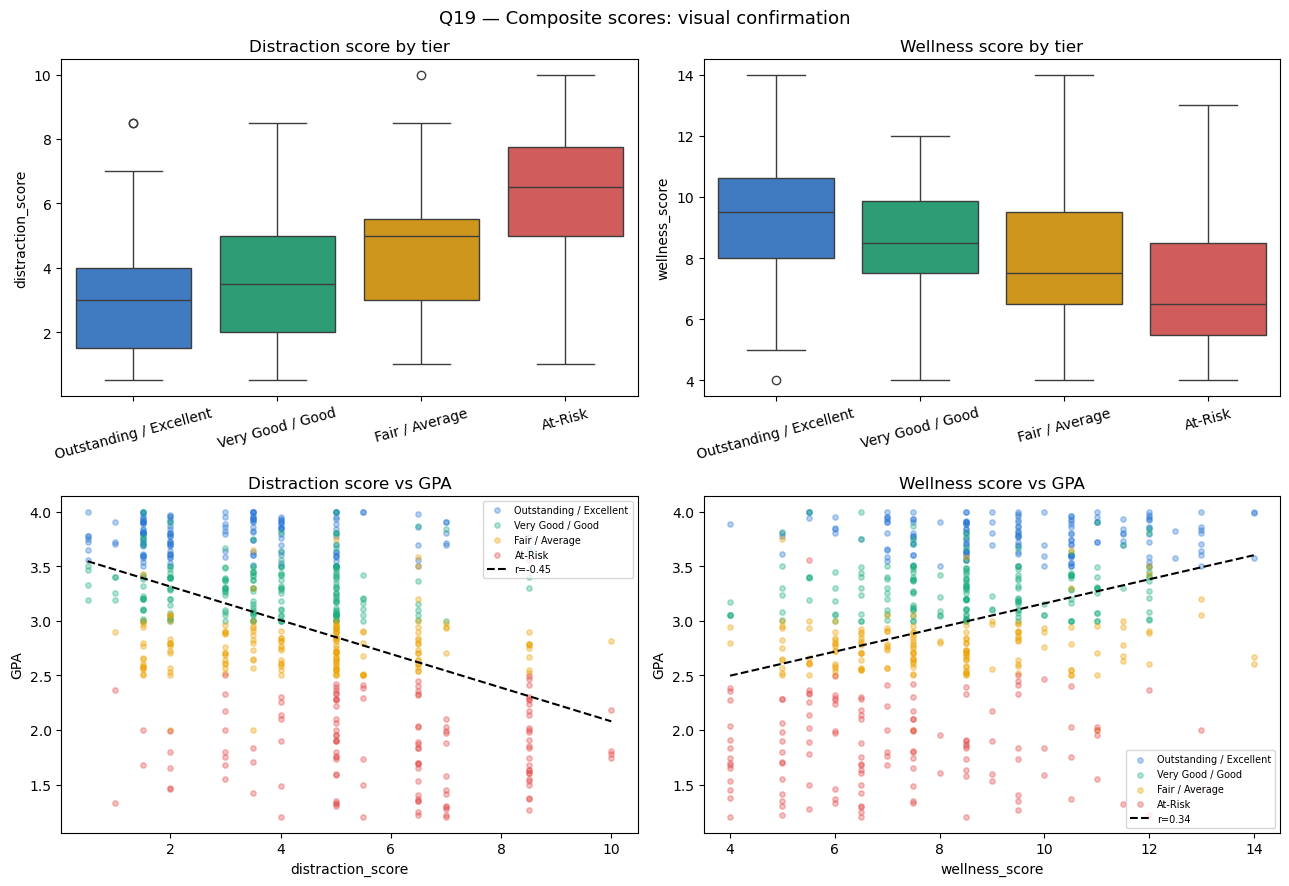

Sleep_Hrs            0.339
wellness_score       0.336
Exercise_Days_Wk     0.192
Social_Media_Hrs    -0.298
Gaming_Hrs          -0.362
distraction_score   -0.448
Name: GPA, dtype: float64


In [34]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, col, title in zip(axes[0],
        ['distraction_score', 'wellness_score'],
        ['Distraction score by tier', 'Wellness score by tier']):
    sns.boxplot(data=df, x='Performance_Tier', y=col,
                order=TIER_ORDER, palette=TIER_COLORS, ax=ax)
    ax.set(title=title, xlabel='')
    ax.tick_params(axis='x', rotation=15)

for ax, col, title in zip(axes[1],
        ['distraction_score', 'wellness_score'],
        ['Distraction score vs GPA', 'Wellness score vs GPA']):
    for tier, color in zip(TIER_ORDER, TIER_COLORS):
        sub = df[df['Performance_Tier'] == tier]
        ax.scatter(sub[col], sub['GPA'], alpha=0.35, s=15, color=color, label=tier)
    m, b, r, *_ = stats.linregress(df[col], df['GPA'])
    x = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x, m*x+b, 'k--', label=f'r={r:.2f}')
    ax.set(xlabel=col, ylabel='GPA', title=title)
    ax.legend(fontsize=7)

plt.suptitle('Q19 — Composite scores: visual confirmation', fontsize=13)
plt.tight_layout(); plt.show()

cols = ['Social_Media_Hrs','Gaming_Hrs','distraction_score','Sleep_Hrs','Exercise_Days_Wk','wellness_score']
print(df[cols+['GPA']].corr()['GPA'].drop('GPA').sort_values(ascending=False).round(3))

---
## Summary

In [ ]:
summary = {
    'Strongest predictor':           'Attendance rate (r=0.51)',
    'Strongest negative predictor':  'Distraction score (r=-0.45)',
    'Regular vs cramming GPA':       f"{df[df.Study_Habit=='Regular study']['GPA'].mean():.2f} vs {df[df.Study_Habit=='Cramming']['GPA'].mean():.2f}",
    'At-Risk mean attendance':       f"{df[df.Performance_Tier=='At-Risk']['Attendance_Rate'].mean():.1f}%",
    'Sleep (Outstanding vs At-Risk)':f"{df[df.Performance_Tier=='Outstanding / Excellent']['Sleep_Hrs'].mean():.1f} vs {df[df.Performance_Tier=='At-Risk']['Sleep_Hrs'].mean():.1f} hrs",
    'Student vs FT worker GPA':      f"{df[df.Employment=='Unemployed / Full-time student']['GPA'].mean():.2f} vs {df[df.Employment=='Working full-time']['GPA'].mean():.2f}",
    'Missing values':                0,
}
print('='*45)
for k, v in summary.items():
    print(f'{k}: {v}')
print('='*45)


Strongest predictor: Attendance rate (r=0.51)
Strongest negative predictor: Distraction score (r=-0.45)
Regular vs cramming GPA: 3.34 vs 2.65
At-Risk mean attendance: 74.5%
Sleep (Outstanding vs At-Risk): 6.8 vs 5.5 hrs
Student vs FT worker GPA: 3.12 vs 2.64
Missing values: 0
